In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import dataloader

# Henter dataframe fra dataloaderen
samlet_df = dataloader.samlet_df

# 2D histogrammer over bestemt kategori for N største kassations-årsager

Genererer plots for 'Bukser' (Top 13 årsager)...


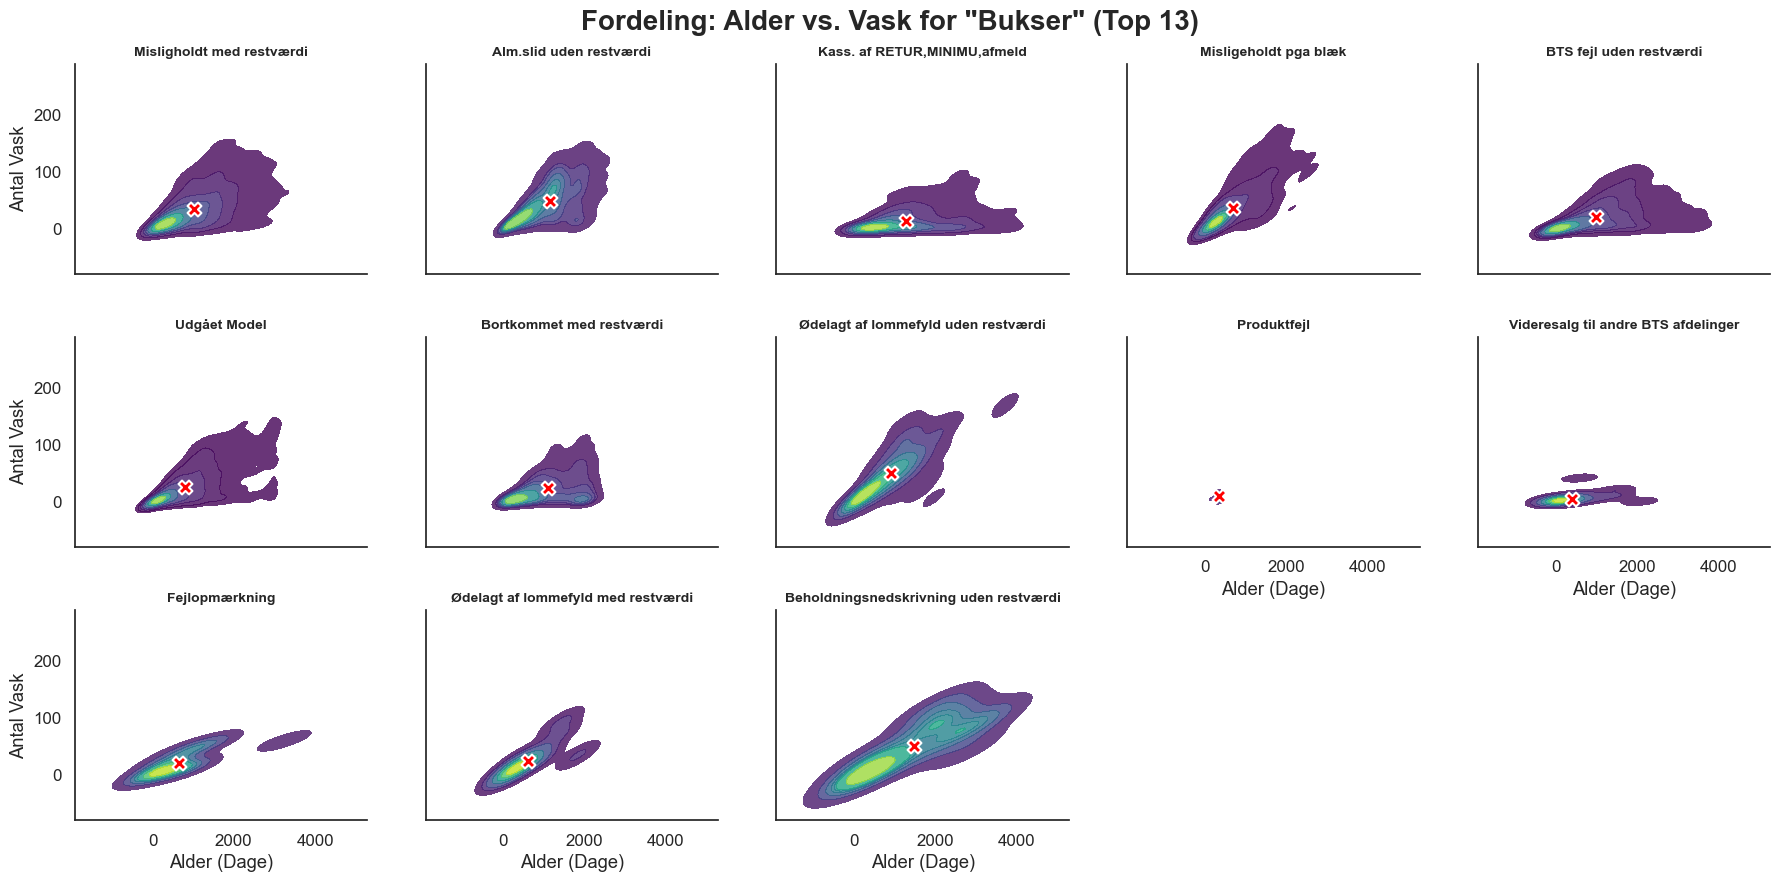

In [ ]:
def fordeling_plots(valgt_kategori, data, N_årsager=15):
    
    print(f"Genererer plots for '{valgt_kategori}' (Top {N_årsager} årsager)...")

    # 1. DATA FORBEREDELSE
    cols = ['Dage i cirkulation', 'Total antal vask']
    for c in cols:
        data[c] = pd.to_numeric(data[c], errors='coerce')

    # Filtrer på kategorien
    if valgt_kategori == 'Alle':
        df_subset = data.copy()
    else:
        df_subset = data[data['Kategori'] == valgt_kategori].copy()

    # 2. FIND DE TOP N ÅRSAGER
    top_årsager = df_subset['Kassationsårsag (ui)'].value_counts().head(N_årsager).index
    df_plot = df_subset[df_subset['Kassationsårsag (ui)'].isin(top_årsager)]

    # 3. RENS DATA (Kun for syns skyld)
    df_plot = df_plot[
        (df_plot['Dage i cirkulation'] < 4000) & 
        (df_plot['Total antal vask'] < 350)
    ]
    
    # 4. FJERN ÅRSAGER MED FOR LIDT DATA
    counts = df_plot['Kassationsårsag (ui)'].value_counts()
    nok_data_årsager = counts[counts > 10].index
    df_plot = df_plot[df_plot['Kassationsårsag (ui)'].isin(nok_data_årsager)]

    # 5. OPSÆT PLOTTET (FacetGrid)
    sns.set_theme(style="white", font_scale=1.1) 
    
    g = sns.FacetGrid(df_plot, col='Kassationsårsag (ui)', col_wrap=5, height=3, aspect=1.2)

    # 6. TEGN DET "PÆNE" PLOT
    g.map_dataframe(
        sns.kdeplot, 
        x='Dage i cirkulation', 
        y='Total antal vask', 
        fill=True, 
        levels=8, 
        cmap="viridis", 
        thresh=0.05,
        alpha=0.8
    )

    # 7. TILFØJ GENNEMSNIT (Rødt kryds)
    def plot_mean(x, y, **kwargs):
        if len(x) > 0:
            plt.scatter(x.mean(), y.mean(), color='red', s=100, marker='X', edgecolors='white', linewidths=1.5, zorder=10)
    
    g.map(plot_mean, 'Dage i cirkulation', 'Total antal vask')

    # 8. PYNT
    g.set_titles(col_template="{col_name}", fontweight='bold', size=10)
    g.set_axis_labels("Alder (Dage)", "Antal Vask")
    
    g.fig.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
    g.fig.suptitle(f'Fordeling: Alder vs. Vask for "{valgt_kategori}" (Top {N_årsager})', fontsize=20, weight='bold')

    plt.show()

# Kør funktionen på den nye samlet_df
fordeling_plots('Bukser', samlet_df, N_årsager=13)

# 2D histogrammer med logaritmisk skala

Genererer plots for 'Bukser' (Top 13 årsager, Enhed: Uger)...


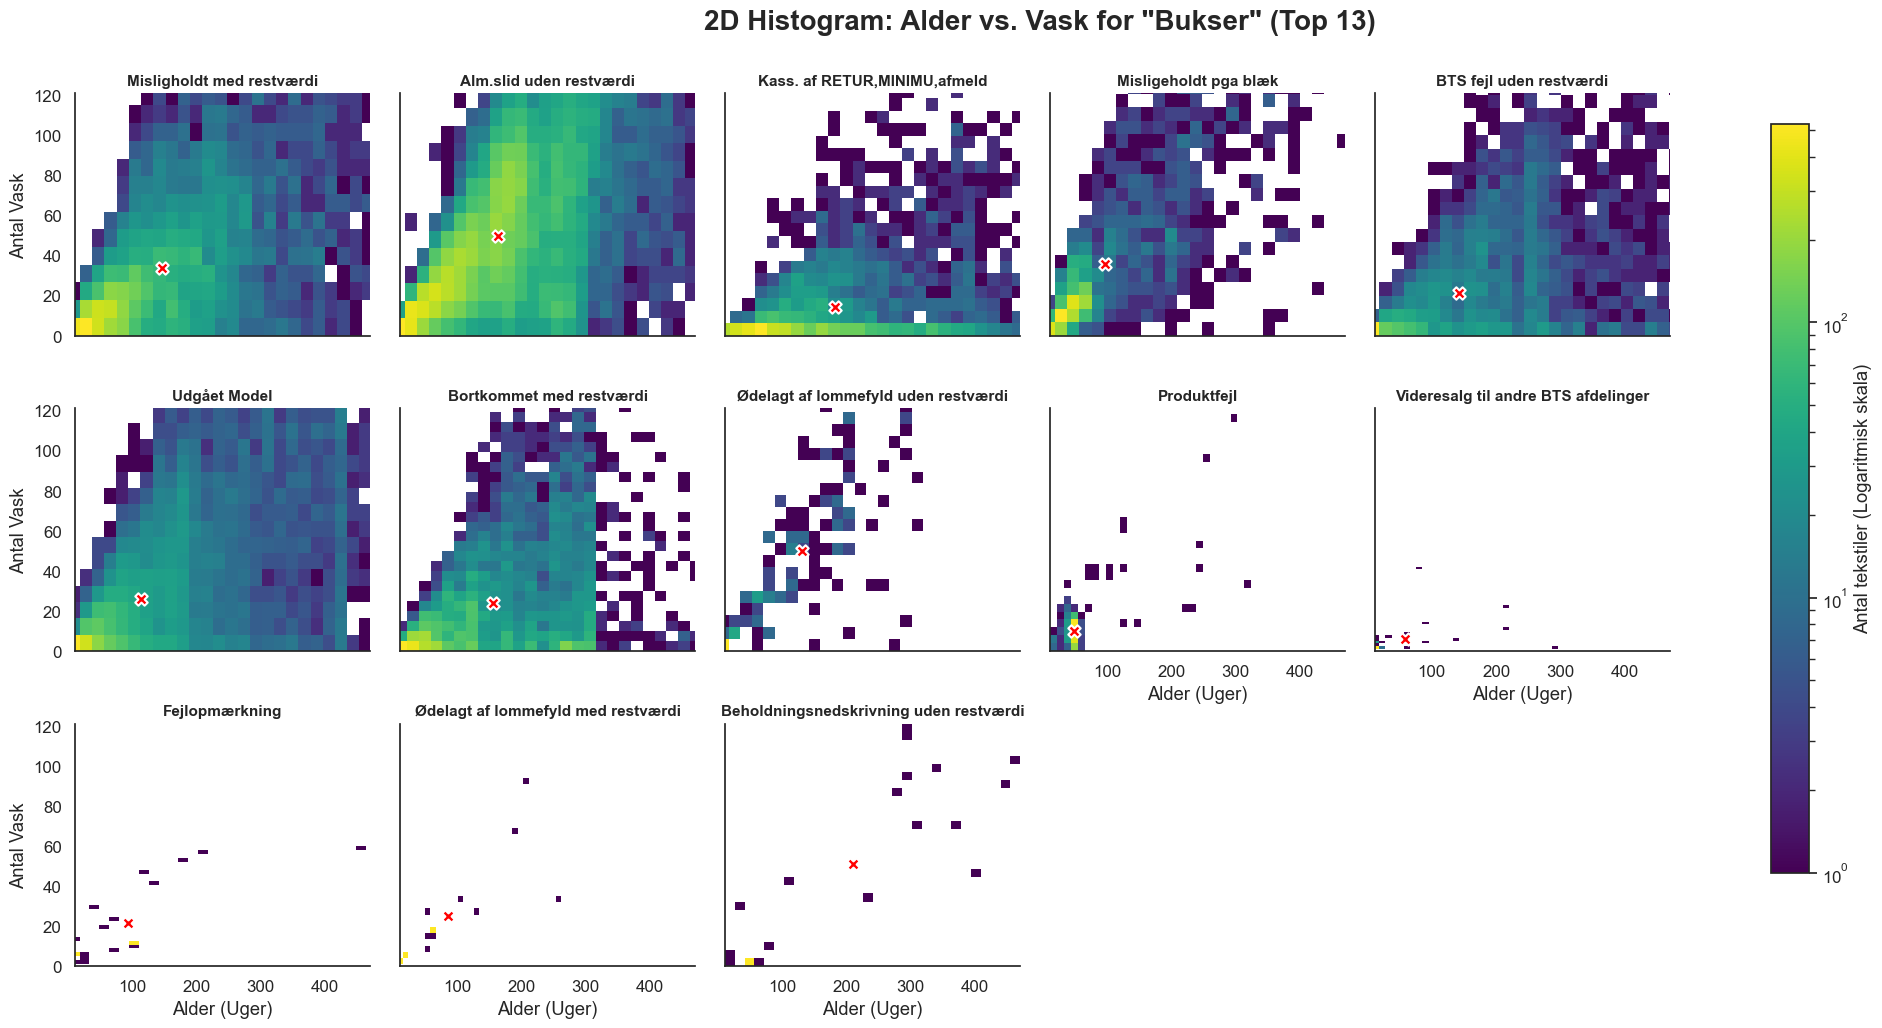

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
import numpy as np

def fordeling_plots_hist(valgt_kategori, data, N_årsager=20, tidsenhed='Dage'):
    
    print(f"Genererer plots for '{valgt_kategori}' (Top {N_årsager} årsager, Enhed: {tidsenhed})...")

    # 1. DATA FORBEREDELSE
    cols = ['Dage i cirkulation', 'Total antal vask']
    for c in cols:
        data[c] = pd.to_numeric(data[c], errors='coerce')

    if valgt_kategori == 'Alle':
        df_subset = data.copy()
    else:
        df_subset = data[data['Kategori'] == valgt_kategori].copy()

    # 2. FIND DE TOP N ÅRSAGER
    top_årsager = df_subset['Kassationsårsag (ui)'].value_counts().head(N_årsager).index
    df_plot = df_subset[df_subset['Kassationsårsag (ui)'].isin(top_årsager)].copy()

    # 3. RENS DATA
    df_plot = df_plot[
        (df_plot['Dage i cirkulation'] < 4000) & 
        (df_plot['Total antal vask'] < 350)
    ]
    
    counts = df_plot['Kassationsårsag (ui)'].value_counts()
    nok_data_årsager = counts[counts > 5].index
    df_plot = df_plot[df_plot['Kassationsårsag (ui)'].isin(nok_data_årsager)]

    # 4. LOGIK FOR TIDSENHED
    tids_valg = tidsenhed.capitalize()
    if tids_valg == 'Uger':
        divisor = 7
    elif tids_valg in ['Måneder', 'Maaneder', 'Måned']:
        divisor = 30.4375
    elif tids_valg in ['År', 'Aar']:
        divisor = 365.25
    else:
        divisor = 1
        tids_valg = 'Dage'

    df_plot['Alder_plottet'] = df_plot['Dage i cirkulation'] / divisor

    # --- 5. LØSNINGEN: FACETGRID + MATPLOTLIB HIST2D ---
    sns.set_theme(style="white", font_scale=1.1) 
    
    g = sns.FacetGrid(
        df_plot,
        col='Kassationsårsag (ui)',
        col_wrap=5,
        height=3.5,
        aspect=1.2
    )

    mappable_imgs = []

    def tegn_log_hist2d(x, y, **kwargs):
        ax = plt.gca()
        valid = ~(x.isna() | y.isna()) 
        
        if valid.sum() > 0:
            counts, xedges, yedges, img = ax.hist2d(
                x[valid], y[valid],
                bins=30,
                cmap="viridis",
                cmin=1,                        
                norm=mcolors.LogNorm(vmin=1)   
            )
            mappable_imgs.append(img)
            
            ax.scatter(x[valid].mean(), y[valid].mean(), 
                       color='red', s=80, marker='X', edgecolors='white', linewidths=1.5, zorder=10)

    g.map(tegn_log_hist2d, 'Alder_plottet', 'Total antal vask')

    # --- 6. TILFØJ DEN FÆLLES COLORBAR OG GØR PLADS ---
    if mappable_imgs:
        cbar = g.figure.colorbar(mappable_imgs[0], ax=g.axes.ravel().tolist(), shrink=0.8, pad=0.03)
        cbar.set_label('Antal tekstiler (Logaritmisk skala)')

    # 7. PYNT OG TITLER
    g.set_titles(col_template="{col_name}", fontweight='bold', size=11)
    g.set_axis_labels(f"Alder ({tids_valg})", "Antal Vask")
    
    g.fig.subplots_adjust(top=0.90, right=0.80, hspace=0.3, wspace=0.1)
    g.fig.suptitle(f'2D Histogram: Alder vs. Vask for "{valgt_kategori}" (Top {N_årsager})', fontsize=20, weight='bold')

    plt.show()

# Kør funktionen
fordeling_plots_hist('Bukser', samlet_df, N_årsager=13, tidsenhed='Uger')

# Histogram for bestemt kategori og årsag

Laver plot for 'T-shirt' med årsag 'Misligholdt med restværdi'...


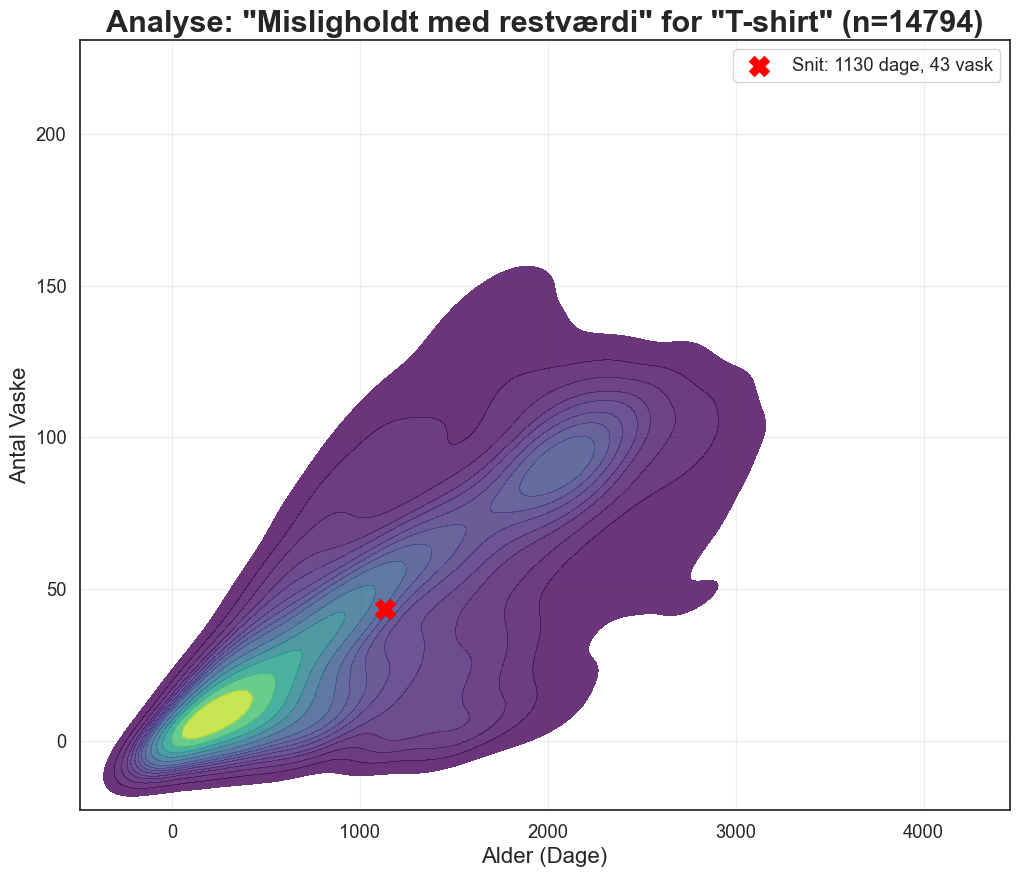

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def lav_aarsag_plot(kategori, aarsag, data):
    print(f"Laver plot for '{kategori}' med årsag '{aarsag}'...")
    
    # 1. FILTRER PÅ PRODUKT
    if kategori == 'Alle':
        df_sub = data.copy()
    else:
        df_sub = data[data['Kategori'] == kategori].copy()
        
    # 2. FILTRER PÅ KASSATIONSÅRSAG DIREKTE
    df_plot = df_sub[df_sub['Kassationsårsag (ui)'] == aarsag]
    
    antal = len(df_plot)
    if antal < 5:
        print(f"FEJL: Kun {antal} observationer fundet for årsagen '{aarsag}'.")
        return

    # Fjern outliers til visning
    if x_max: df_plot = df_plot[df_plot['Dage i cirkulation'] < x_max]
    if y_max: df_plot = df_plot[df_plot['Total antal vask'] < y_max]

    # 3. PLOT
    plt.figure(figsize=(12, 10))
    sns.set_theme(style="white", font_scale=1.2)
    
    sns.kdeplot(
        data=df_plot,
        x='Dage i cirkulation',
        y='Total antal vask',
        fill=True,
        levels=15, 
        cmap="viridis", 
        thresh=0.05,
        alpha=0.8
    )
    
    # Gennemsnit
    avg_x = df_plot['Dage i cirkulation'].mean()
    avg_y = df_plot['Total antal vask'].mean()
    plt.scatter(avg_x, avg_y, color='red', s=200, marker='X', zorder=10, 
                label=f'Snit: {int(avg_x)} dage, {int(avg_y)} vask')

    plt.title(f'Analyse: "{aarsag}" for "{kategori}" (n={antal})', fontsize=22, weight='bold')
    plt.xlabel('Alder (Dage)', fontsize=16)
    plt.ylabel('Antal Vaske', fontsize=16)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- INDSTILLINGER ---
valgt_kategori = 'T-shirt'   
# Indsæt en rigtig årsag fra systemet nu (fx 'Udgået Model', 'Misligholdt pga blæk' osv.)
valgt_aarsag = 'Misligholdt med restværdi'  

# Zoom (Sæt til None for auto)
x_max = 4000 
y_max = 300

# Kør plottet med dataloaderens dataframe
lav_aarsag_plot(valgt_kategori, valgt_aarsag, samlet_df)

# Anden slags histogram for bestemet kategori og årsag

Plot for 'T-shirt' med årsag 'Misligholdt med restværdi'...


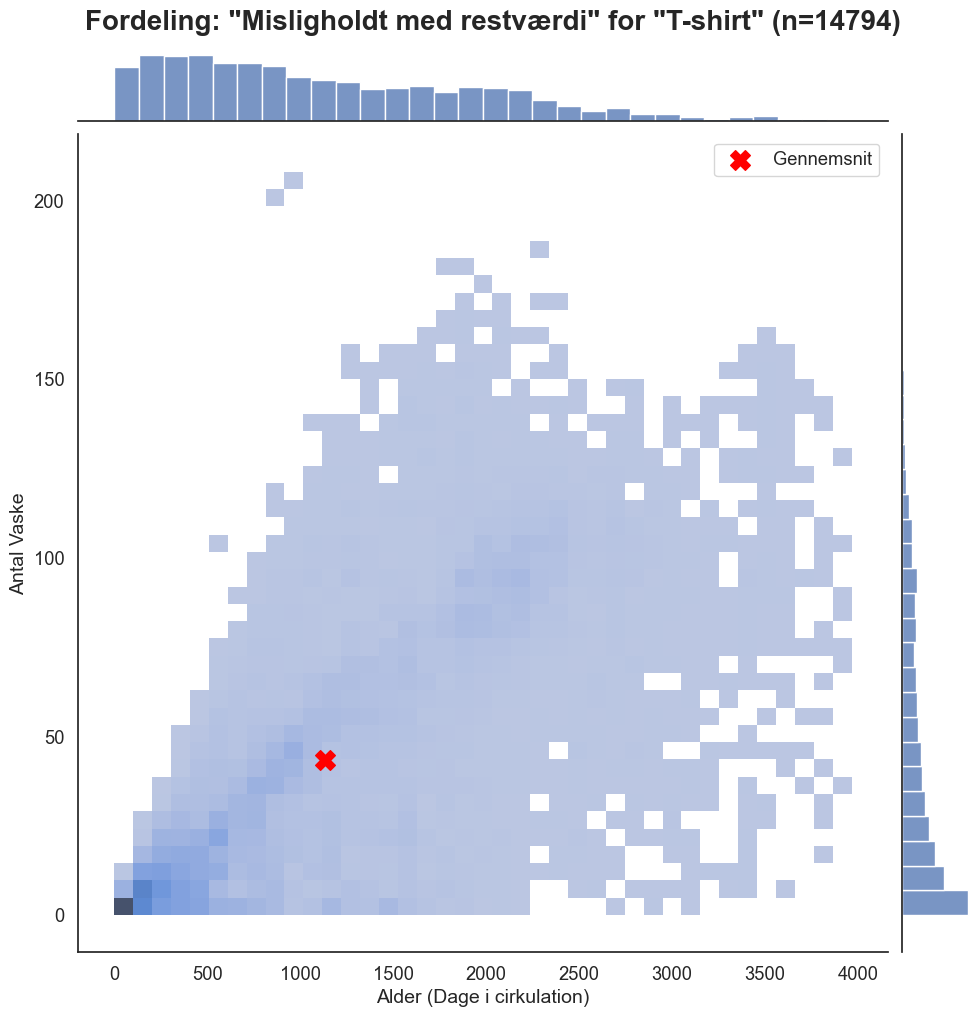

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def lav_hist_plot(kategori, aarsag, data):
    print(f"Plot for '{kategori}' med årsag '{aarsag}'...")
    
    # Filtrer på Kategori
    if kategori == 'Alle':
        df_sub = data.copy()
    else:
        df_sub = data[data['Kategori'] == kategori].copy()
        
    # Filtrer på Årsag
    df_plot = df_sub[df_sub['Kassationsårsag (ui)'] == aarsag]
    
    antal = len(df_plot)
    if antal < 10:
        print(f"FEJL: Kun {antal} observationer. Plottet kræver mere data.")
        return

    # Fjern outliers 
    if x_max: df_plot = df_plot[df_plot['Dage i cirkulation'] < x_max]
    if y_max: df_plot = df_plot[df_plot['Total antal vask'] < y_max]

    # --- LAV PLOTTET (JOINTPLOT) ---
    sns.set_theme(style="white", font_scale=1.2)
    
    g = sns.jointplot(
        data=df_plot,
        x='Dage i cirkulation',
        y='Total antal vask',
        kind='hist',        
        height=10,         
        ratio=10,           
            
        marginal_kws=dict(bins=30, fill=True) 
    )
    
    g.fig.suptitle(f'Fordeling: "{aarsag}" for "{kategori}" (n={antal})', fontsize=20, weight='bold', y=1.02)
    g.set_axis_labels('Alder (Dage i cirkulation)', 'Antal Vaske', fontsize=14)
    
    avg_x = df_plot['Dage i cirkulation'].mean()
    avg_y = df_plot['Total antal vask'].mean()
    g.ax_joint.scatter(avg_x, avg_y, color='red', s=200, marker='X', zorder=10, label='Gennemsnit')
    g.ax_joint.legend(loc='upper right')

    plt.show()

# Kør funktionen
lav_hist_plot('T-shirt', 'Misligholdt med restværdi', samlet_df)